# Agricultural Commodity Price Prediction Using Machine Learning


## Aim

To develop a machine learning model for predicting agricultural commodity prices using historical market data, exploratory data analysis, regression techniques, hyperparameter tuning, and a RAG-based price query system.

## Problem Statement

Develop a machine learning model to predict the prices of agricultural commodities like onions, potatoes, and pulses. Commodity price fluctuations affect both farmers and consumers. A machine learning model using time-series forecasting and regression techniques can predict future prices based on historical market trends, seasonal patterns, and weather data, helping stakeholders make informed decisions.

## Dataset Description

The dataset contains agricultural commodity market information collected from different states, districts, and markets.

It contains the following attributes:

- State
- District
- Market
- Commodity
- Variety
- Grade
- Arrival Date
- Minimum Price
- Maximum Price
- Modal Price

The dataset contains **6862 records and 10 attributes**.

## Prompt Used for Dataset Collection

The following prompt was used to identify a suitable dataset for agricultural commodity price prediction:

**Prompt:**

"Find a suitable dataset for predicting agricultural commodity prices using machine learning. The dataset should contain information such as State, District, Market, Commodity, Variety, Grade, Arrival Date, Minimum Price, Maximum Price and Modal Price. Provide the dataset in CSV format so that it can be used for exploratory data analysis, regression modelling, hyperparameter tuning and price prediction."

**Purpose of the Prompt:**

The prompt was used to identify a dataset containing agricultural commodity market information and price attributes required for developing the machine learning model.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the Dataset

file_path = r"E:\ML ASSIGNMENT 2\Agricultural_Price_Prediction.csv"

df = pd.read_csv(file_path)

# Step 3: Display the Dataset

print("Dataset Loaded Successfully")

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Loaded Successfully

First 5 Rows:


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
0,Andhra Pradesh,Prakasam,Maddipadu APMC,Paddy(Common),B P T,FAQ,21/09/2026,2800.0,2800.0,2800.0
1,Haryana,Rewari,Kosli APMC,Bhindi(Ladies Finger),Bhindi,FAQ,21/09/2026,2000.0,2000.0,2000.0
2,Haryana,Rewari,Kosli APMC,Banana,Other,Medium,21/09/2026,2000.0,2000.0,2000.0
3,Haryana,Rewari,Kosli APMC,Cabbage,Other,FAQ,21/09/2026,2000.0,2000.0,2000.0
4,Haryana,Rewari,Kosli APMC,Pumpkin,Other,FAQ,21/09/2026,1000.0,1000.0,1000.0



Dataset Shape:
(6862, 10)

Column Names:
['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Arrival_Date', 'Min_x0020_Price', 'Max_x0020_Price', 'Modal_x0020_Price']


## Data Understanding

The dataset is inspected to understand its structure, data types, missing values, duplicate records, and basic statistical information.

In [5]:
# Step 4: Dataset Inspection

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nNumber of Unique Commodities:")
print(df["Commodity"].nunique())

print("\nTop 10 Commodities:")
display(df["Commodity"].value_counts().head(10))

print("\nUnique Arrival Dates:")
print(df["Arrival_Date"].nunique())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6862 entries, 0 to 6861
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              6862 non-null   object 
 1   District           6862 non-null   object 
 2   Market             6862 non-null   object 
 3   Commodity          6862 non-null   object 
 4   Variety            6862 non-null   object 
 5   Grade              6862 non-null   object 
 6   Arrival_Date       6862 non-null   object 
 7   Min_x0020_Price    6862 non-null   float64
 8   Max_x0020_Price    6862 non-null   float64
 9   Modal_x0020_Price  6862 non-null   float64
dtypes: float64(3), object(7)
memory usage: 536.2+ KB

Missing Values:
State                0
District             0
Market               0
Commodity            0
Variety              0
Grade                0
Arrival_Date         0
Min_x0020_Price      0
Max_x0020_Price      0
Modal_x0020_Price 

,Min_x0020_Price,Max_x0020_Price,Modal_x0020_Price
count,6862.000000,6862.000000,6862.000000
mean,5294.379370,5989.749573,5643.603868
std,6206.555954,6658.118495,6399.744530
min,0.010000,0.010000,0.010000
25%,2800.000000,3000.000000,3000.000000
50%,4000.000000,4500.000000,4250.000000
75%,6000.000000,6500.000000,6000.000000
max,320000.000000,320000.000000,320000.000000



Number of Unique Commodities:
139

Top 10 Commodities:


Commodity
Brinjal                  213
Tomato                   200
Bhindi(Ladies Finger)    197
Green Chilli             184
Bottle gourd             184
Onion                    183
Bitter gourd             182
Potato                   175
Banana                   173
Pumpkin                  162
Name: count, dtype: int64


Unique Arrival Dates:
1


In [7]:
# Step 5: Descriptive Statistics

price_columns = [
    "Min_x0020_Price",
    "Max_x0020_Price",
    "Modal_x0020_Price"
]

print("Mean of Price Columns:")
display(df[price_columns].mean())

print("\nMedian of Price Columns:")
display(df[price_columns].median())

print("\nMode of Price Columns:")
display(df[price_columns].mode().iloc[0])

Mean of Price Columns:


Min_x0020_Price      5294.379370
Max_x0020_Price      5989.749573
Modal_x0020_Price    5643.603868
dtype: float64


Median of Price Columns:


Min_x0020_Price      4000.0
Max_x0020_Price      4500.0
Modal_x0020_Price    4250.0
dtype: float64


Mode of Price Columns:


Min_x0020_Price      3000.0
Max_x0020_Price      4000.0
Modal_x0020_Price    3750.0
Name: 0, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of agricultural commodity prices, compare commodities and grades, and identify relationships among minimum, maximum, and modal prices.

## Plot 1: Distribution of Agricultural Commodity Modal Prices

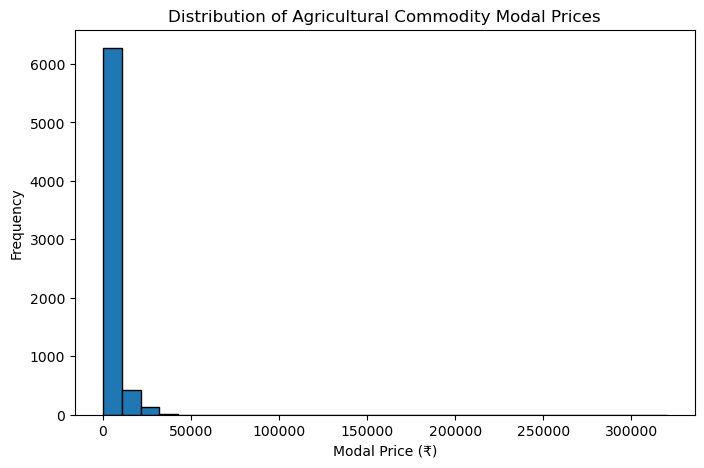

In [8]:
# Step 6: Histogram of Modal Price

plt.figure(figsize=(8, 5))

plt.hist(df["Modal_x0020_Price"], bins=30, edgecolor="black")

plt.title("Distribution of Agricultural Commodity Modal Prices")
plt.xlabel("Modal Price (₹)")
plt.ylabel("Frequency")

plt.show()

### Insight

The histogram shows that most modal price values are concentrated in the lower price range, while a smaller number of observations have very high modal prices.

### Inference

This indicates that lower-priced commodities are more frequently represented in the dataset, while high-priced observations occur less frequently. The distribution is right-skewed due to the presence of high-price observations.

## Plot 2: Distribution of Agricultural Commodity Minimum Prices

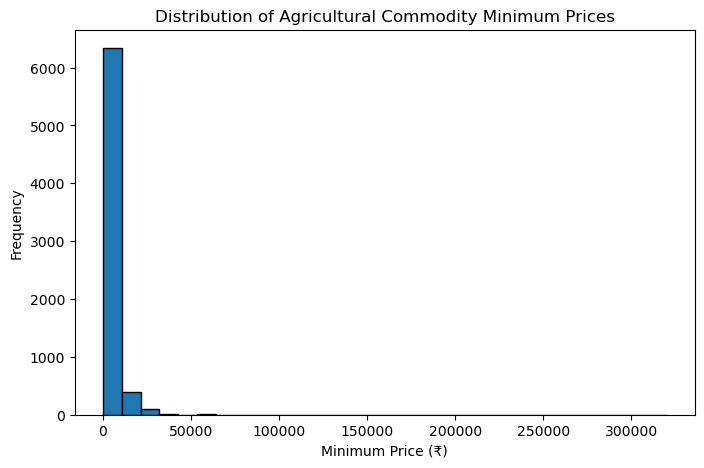

In [9]:
# Plot 2: Distribution of Minimum Price

plt.figure(figsize=(8, 5))

plt.hist(df["Min_x0020_Price"], bins=30,
         edgecolor="black")

plt.title("Distribution of Agricultural Commodity Minimum Prices")
plt.xlabel("Minimum Price (₹)")
plt.ylabel("Frequency")

plt.show()

### Insight

The histogram shows that most minimum price values are concentrated in the lower price range, while a smaller number of observations have very high minimum prices.

### Inference

This indicates that lower minimum prices are more frequently observed across the agricultural commodities, while high minimum price values occur less frequently. The distribution is right-skewed due to the presence of some high-price observations.

## Plot 3: Distribution of Agricultural Commodity Maximum Prices

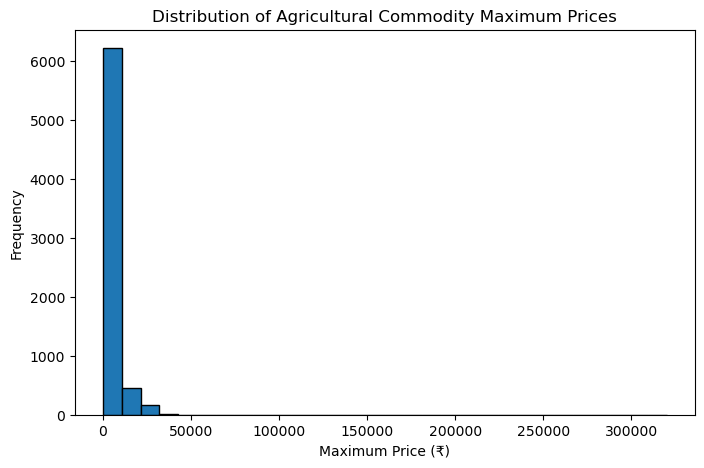

In [10]:
# Plot 3: Distribution of Maximum Price

plt.figure(figsize=(8, 5))

plt.hist(df["Max_x0020_Price"], bins=30,
         edgecolor="black")

plt.title("Distribution of Agricultural Commodity Maximum Prices")
plt.xlabel("Maximum Price (₹)")
plt.ylabel("Frequency")

plt.show()

### Insight

The histogram shows that most maximum price values are concentrated in the lower price range, while a smaller number of observations have very high maximum prices.

### Inference

This indicates that lower maximum price values are more frequently observed in the dataset, while high maximum price values occur less frequently. The distribution is right-skewed because of the presence of some high-price observations.

## Plot 4: Top 10 Most Frequent Agricultural Commodities

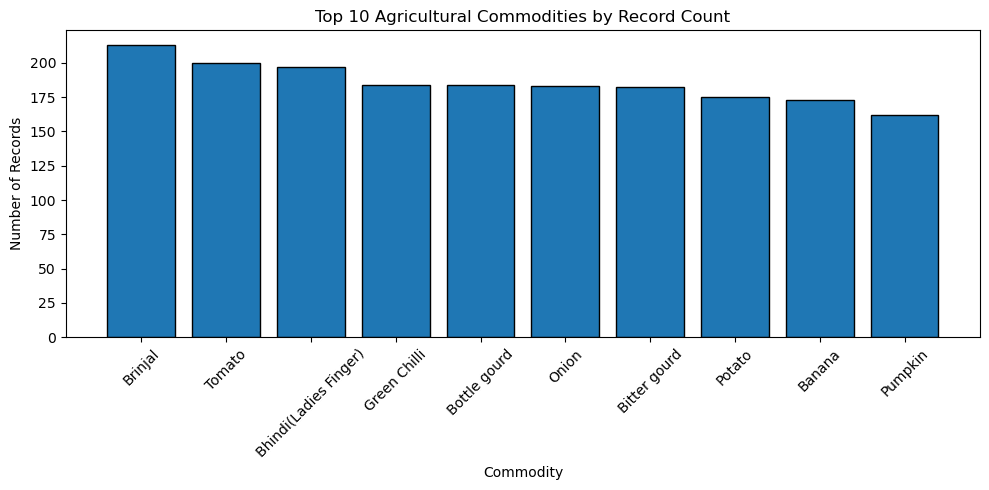

In [11]:
# Plot 4: Top 10 Commodities by Record Count

top_commodities = df["Commodity"].value_counts().head(10)

plt.figure(figsize=(10, 5))

plt.bar(top_commodities.index, top_commodities.values,
        edgecolor="black")

plt.title("Top 10 Agricultural Commodities by Record Count")
plt.xlabel("Commodity")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart shows the top 10 agricultural commodities based on their number of records in the dataset. Brinjal, Tomato, and Bhindi are among the most frequently recorded commodities.

### Inference

This indicates that these commodities have a relatively higher representation in the dataset, while other commodities have fewer records. The variation in record counts shows that the dataset does not contain an equal number of observations for every commodity.

## Plot 5: Average Modal Price of Top 10 Commodities

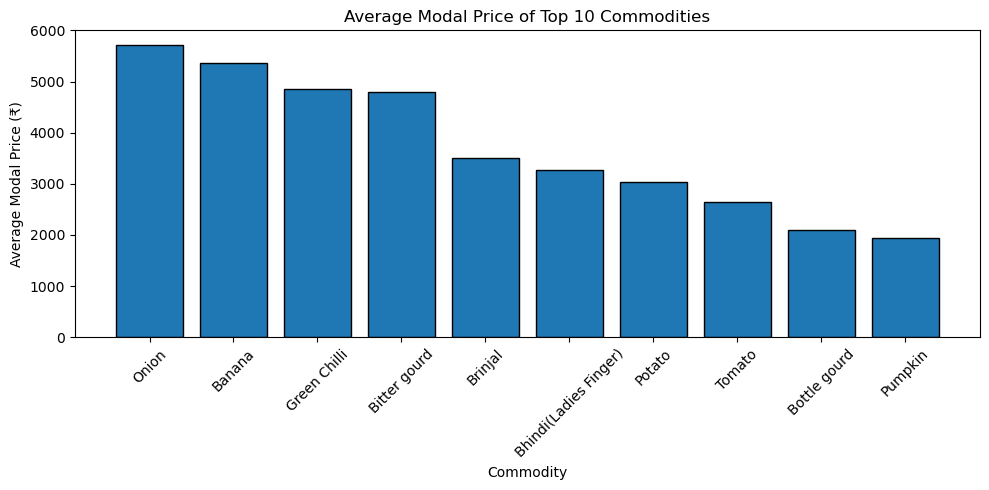

In [12]:
# Plot 5: Average Modal Price of Top 10 Commodities

top_commodities = df["Commodity"].value_counts().head(10).index

commodity_prices = df[df["Commodity"].isin(top_commodities)]

avg_modal_price = commodity_prices.groupby("Commodity")["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(avg_modal_price.index, avg_modal_price.values,
        edgecolor="black")

plt.title("Average Modal Price of Top 10 Commodities")
plt.xlabel("Commodity")
plt.ylabel("Average Modal Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart compares the average modal prices of the top 10 most frequently recorded commodities. The average modal price varies across the commodities.

### Inference

This indicates that different commodities have different market price levels. The variation in average modal prices shows that commodity type is an important factor to consider when predicting agricultural prices.

## Plot 6: Average Modal Price by State

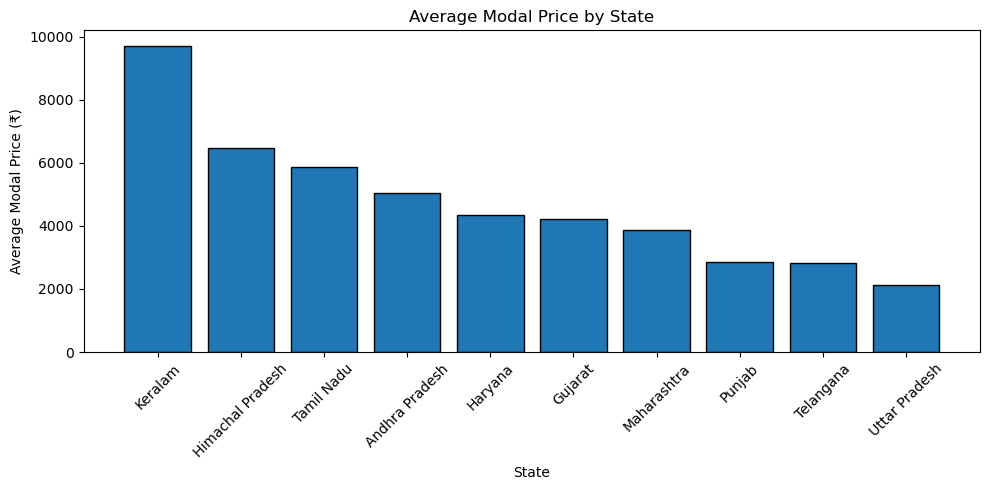

In [13]:
# Plot 6: Average Modal Price by State

top_states = df["State"].value_counts().head(10).index

state_data = df[df["State"].isin(top_states)]

avg_state_price = state_data.groupby("State")["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(avg_state_price.index, avg_state_price.values,
        edgecolor="black")

plt.title("Average Modal Price by State")
plt.xlabel("State")
plt.ylabel("Average Modal Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart shows the average modal price of agricultural commodities across different states. The average modal price varies from one state to another.

### Inference

This indicates that geographical location can be associated with differences in agricultural commodity prices. Therefore, State can be considered an important feature for predicting modal prices.

## Plot 7: Modal Price Distribution by Commodity

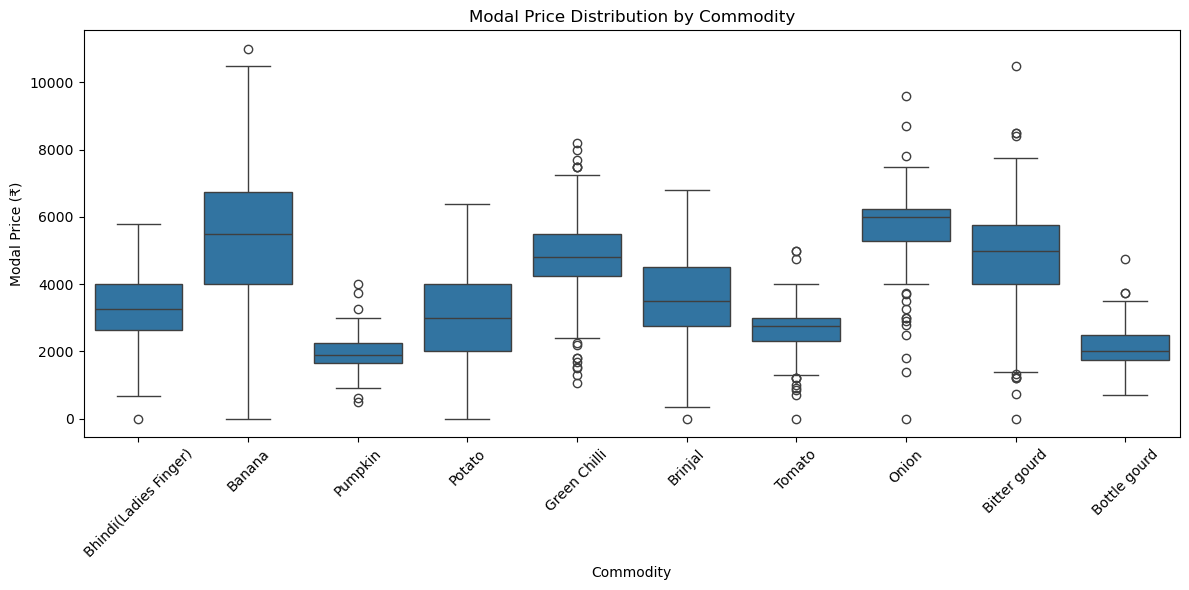

In [14]:
# Plot 7: Box Plot of Modal Price by Commodity

top_commodities = df["Commodity"].value_counts().head(10).index

plot_data = df[df["Commodity"].isin(top_commodities)]

plt.figure(figsize=(12, 6))

sns.boxplot(data=plot_data,
            x="Commodity",
            y="Modal_x0020_Price")

plt.title("Modal Price Distribution by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Modal Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The box plot shows the distribution of modal prices for the top 10 most frequently recorded commodities. The median, spread, and outliers vary across different commodities.

### Inference

This indicates that agricultural commodity prices differ in their central values and variability. The presence of outliers shows that some commodities have occasional observations with unusually high modal prices.

## Plot 8: Minimum Price Distribution by Grade

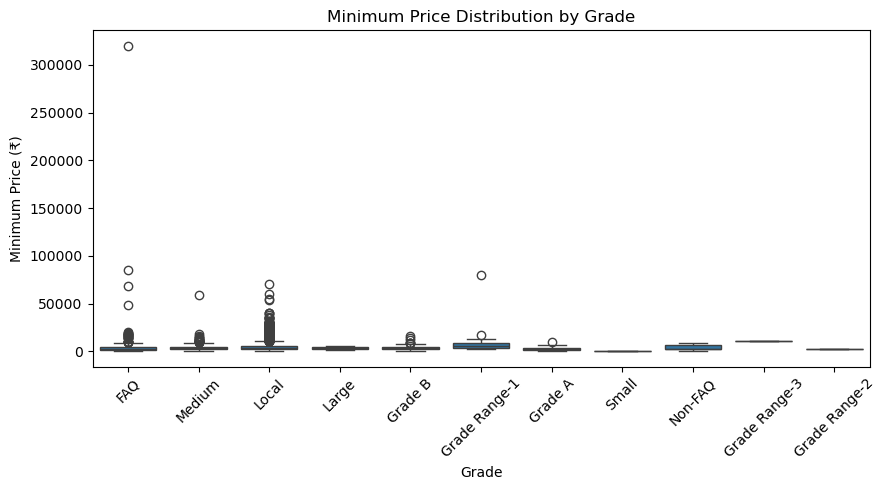

In [15]:
# Plot 8: Minimum Price by Grade

plt.figure(figsize=(9, 5))

sns.boxplot(data=df,
            x="Grade",
            y="Min_x0020_Price")

plt.title("Minimum Price Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Minimum Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The box plot shows the distribution of minimum prices across different grades. The median, spread, and outliers vary between the grades.

### Inference

This indicates that grade is associated with differences in minimum price levels. The variation and outliers suggest that the quality or grade of a commodity can influence its market price.

## Plot 9: Maximum Price Distribution by Grade

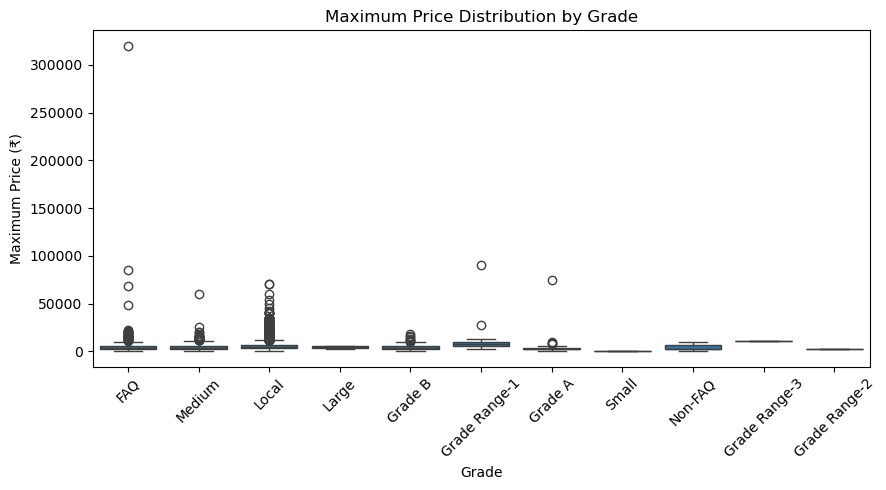

In [16]:
# Plot 9: Maximum Price by Grade

plt.figure(figsize=(9, 5))

sns.boxplot(data=df,
            x="Grade",
            y="Max_x0020_Price")

plt.title("Maximum Price Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Maximum Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The box plot shows the distribution of maximum prices across different grades. The median, spread, and outliers vary between the grades.

### Inference

This indicates that maximum price levels differ across commodity grades. The variation in price distribution suggests that grade can be useful when analysing and predicting agricultural commodity prices.

## Plot 10: Relationship Between Minimum Price and Modal Price

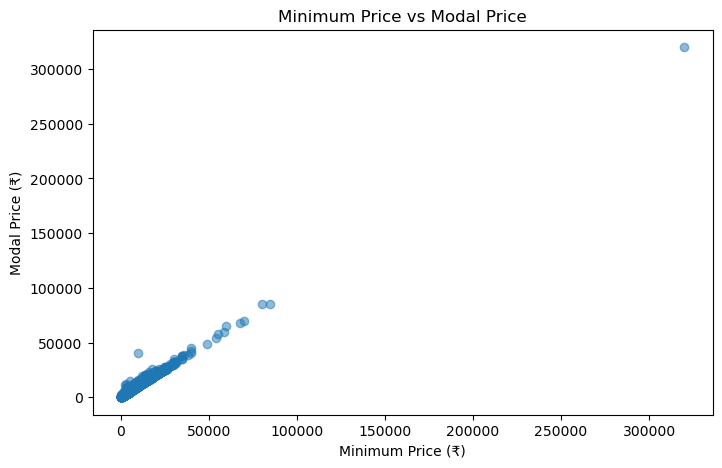

In [17]:
# Plot 10: Minimum Price vs Modal Price

plt.figure(figsize=(8, 5))

plt.scatter(df["Min_x0020_Price"],
            df["Modal_x0020_Price"],
            alpha=0.5)

plt.title("Minimum Price vs Modal Price")
plt.xlabel("Minimum Price (₹)")
plt.ylabel("Modal Price (₹)")

plt.show()

### Insight

The scatter plot shows the relationship between minimum price and modal price. The points generally show an upward pattern, indicating that modal price tends to increase as minimum price increases.

### Inference

This indicates a positive relationship between minimum price and modal price. Minimum price can therefore provide useful information for understanding variations in modal price.

## Plot 11: Relationship Between Maximum Price and Modal Price

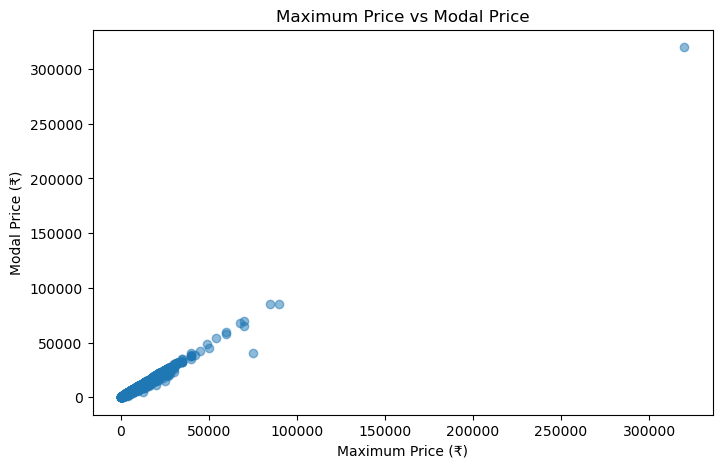

In [18]:
# Plot 11: Maximum Price vs Modal Price

plt.figure(figsize=(8, 5))

plt.scatter(df["Max_x0020_Price"],
            df["Modal_x0020_Price"],
            alpha=0.5)

plt.title("Maximum Price vs Modal Price")
plt.xlabel("Maximum Price (₹)")
plt.ylabel("Modal Price (₹)")

plt.show()

### Insight

The scatter plot shows the relationship between maximum price and modal price. The points generally show an upward pattern, indicating that modal price tends to increase as maximum price increases.

### Inference

This indicates a positive relationship between maximum price and modal price. Maximum price can therefore provide useful information for understanding variations in modal price.

## Plot 12: Relationship Between Minimum Price and Maximum Price

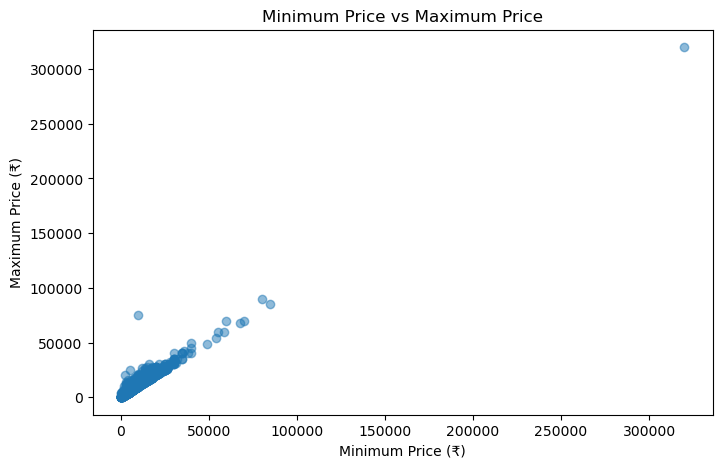

In [19]:
# Plot 12: Minimum Price vs Maximum Price

plt.figure(figsize=(8, 5))

plt.scatter(df["Min_x0020_Price"],
            df["Max_x0020_Price"],
            alpha=0.5)

plt.title("Minimum Price vs Maximum Price")
plt.xlabel("Minimum Price (₹)")
plt.ylabel("Maximum Price (₹)")

plt.show()

### Insight

The scatter plot shows the relationship between minimum price and maximum price. The points show a clear upward pattern, indicating that maximum price generally increases as minimum price increases.

### Inference

This indicates a strong positive relationship between minimum price and maximum price. The relationship shows that both price measures tend to move together across the agricultural commodity records.

## Plot 13: Correlation Heatmap of Price Variables

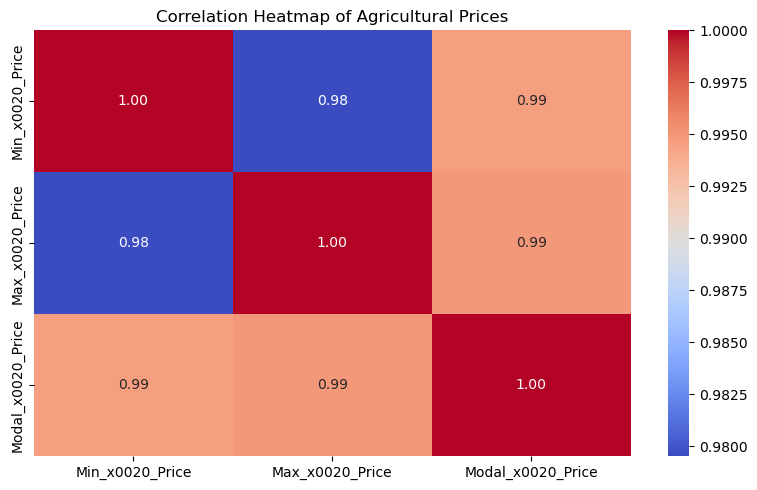

In [20]:
# Plot 13: Correlation Heatmap

price_corr = df[[
    "Min_x0020_Price",
    "Max_x0020_Price",
    "Modal_x0020_Price"
]].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(price_corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap of Agricultural Prices")
plt.tight_layout()
plt.show()

### Insight

The heatmap shows the correlation between minimum price, maximum price, and modal price. The price variables show positive relationships with each other.

### Inference

This indicates that the three price variables tend to move together. The correlation information helps identify relationships among the price attributes and can support feature selection for the prediction model.

## Plot 14: Average Minimum, Maximum and Modal Prices

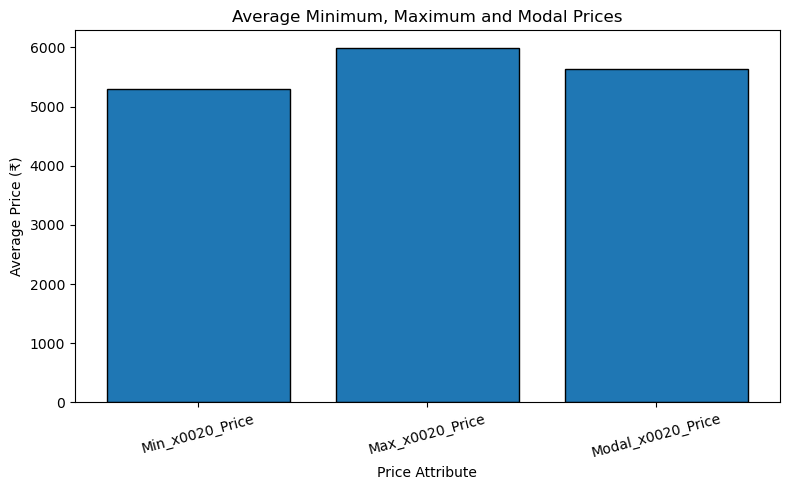

In [21]:
# Plot 14: Average Agricultural Price Comparison

avg_prices = df[[
    "Min_x0020_Price",
    "Max_x0020_Price",
    "Modal_x0020_Price"
]].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_prices.index, avg_prices.values,
        edgecolor="black")

plt.title("Average Minimum, Maximum and Modal Prices")
plt.xlabel("Price Attribute")
plt.ylabel("Average Price (₹)")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Insight

The bar chart compares the average minimum, maximum, and modal prices in the dataset. The average maximum price is higher than the average modal price, while the average minimum price is lower.

### Inference

This indicates that the three price measures represent different levels of market pricing. The modal price lies between the average minimum and maximum prices and can therefore be used as the target variable for price prediction.

## Plot 15: Average Modal Price by Grade

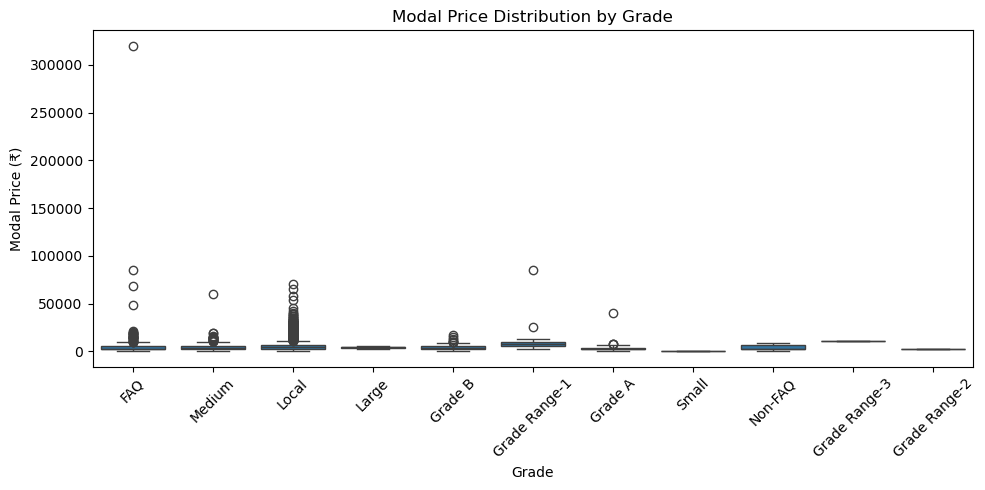

In [22]:
# Plot 15: Modal Price by Grade

plt.figure(figsize=(10, 5))

sns.boxplot(data=df,
            x="Grade",
            y="Modal_x0020_Price")

plt.title("Modal Price Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Modal Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart compares the average modal prices across different grades. The average modal price varies between the grades.

### Inference

This indicates that grade is associated with differences in the average modal price of agricultural commodities. Therefore, Grade can be considered as a relevant categorical feature for price prediction.

## Plot 16: Average Modal Price by Top 10 Districts

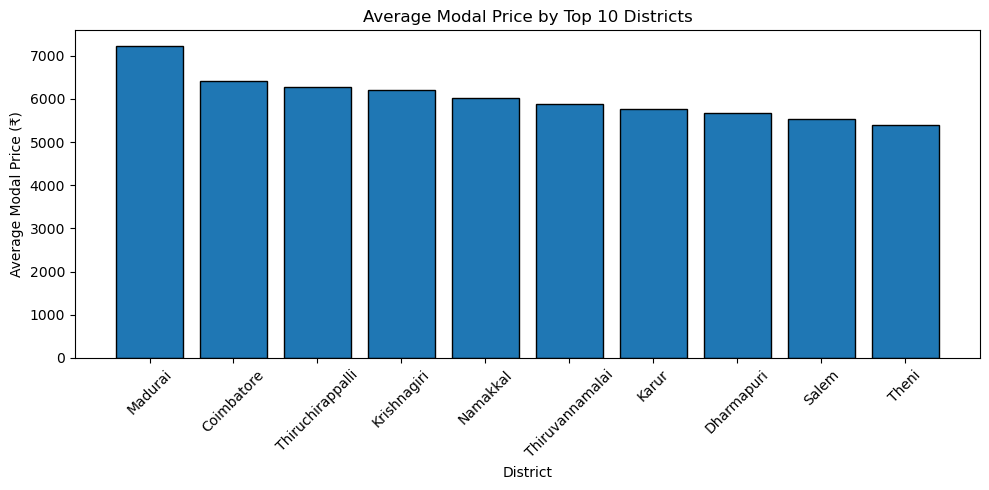

In [23]:
# Plot 16: Average Modal Price by Top 10 Districts

top_districts = df["District"].value_counts().head(10).index

district_data = df[df["District"].isin(top_districts)]

avg_district_price = district_data.groupby(
    "District"
)["Modal_x0020_Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(avg_district_price.index,
        avg_district_price.values,
        edgecolor="black")

plt.title("Average Modal Price by Top 10 Districts")
plt.xlabel("District")
plt.ylabel("Average Modal Price (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart compares the average modal prices across the top 10 districts based on the number of records. The average modal price varies between the districts.

### Inference

This indicates that district-level market conditions are associated with differences in agricultural commodity prices. Therefore, District can be considered as a relevant feature for predicting modal prices.

## Plot 17: Modal Price Distribution by Top 10 Commodities

<Figure size 1200x600 with 0 Axes>

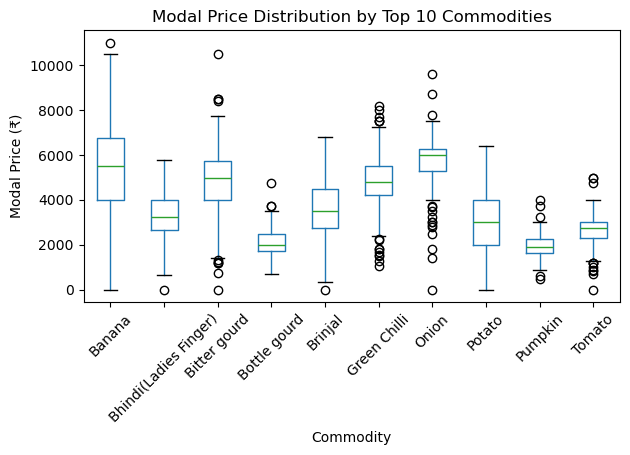

In [24]:
top_commodities = df["Commodity"].value_counts().head(10).index

plot_data = df[df["Commodity"].isin(top_commodities)]

plt.figure(figsize=(12, 6))

plot_data.boxplot(
    column="Modal_x0020_Price",
    by="Commodity",
    grid=False
)

plt.title("Modal Price Distribution by Top 10 Commodities")
plt.suptitle("")
plt.xlabel("Commodity")
plt.ylabel("Modal Price (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The box plot shows the distribution of modal prices for the top 10 most frequently recorded commodities. The median, spread, and outliers vary across the commodities.

### Inference

This indicates that different commodities have different modal price levels and price variability. The presence of outliers shows that some commodities have occasional observations with unusually high modal prices.

## Plot 18: Modal Price vs Maximum Price

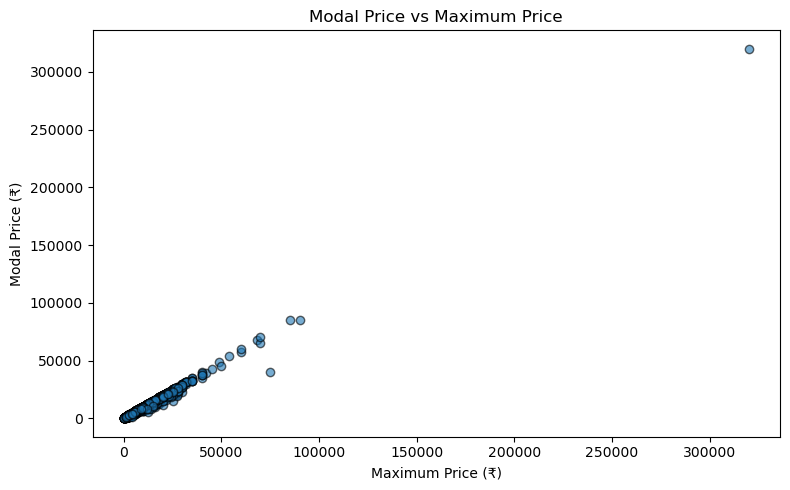

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Max_x0020_Price"],
    df["Modal_x0020_Price"],
    edgecolor="black",
    alpha=0.6
)

plt.title("Modal Price vs Maximum Price")
plt.xlabel("Maximum Price (₹)")
plt.ylabel("Modal Price (₹)")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows the relationship between maximum price and modal price. The points show an overall upward pattern, indicating that higher maximum prices are generally associated with higher modal prices.

### Inference

This indicates a positive relationship between maximum price and modal price. Maximum Price therefore provides useful information for understanding variations in the Modal Price.

## Plot 19: Number of Records by Grade

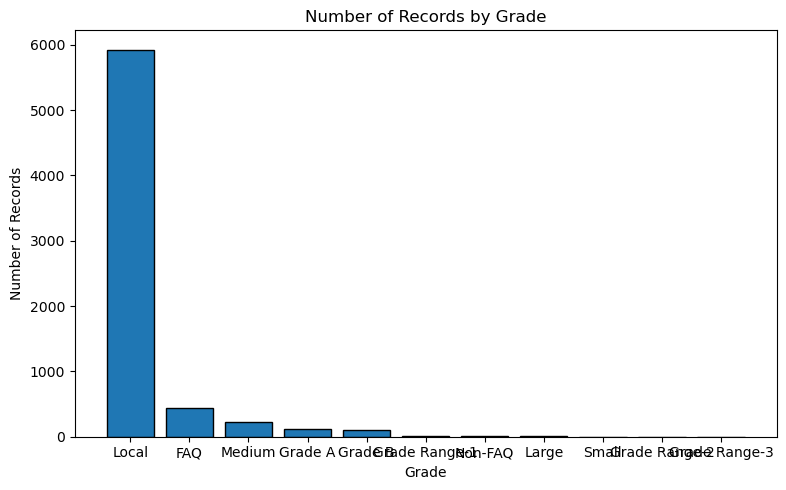

In [26]:
grade_counts = df["Grade"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    grade_counts.index.astype(str),
    grade_counts.values,
    edgecolor="black"
)

plt.title("Number of Records by Grade")
plt.xlabel("Grade")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Insight

The bar chart shows the number of records available for each grade in the dataset. The number of observations varies across the different grades.

### Inference

This indicates that the dataset does not contain an equal number of records for every grade. The distribution of records across grades should be considered when analysing the effect of Grade on agricultural commodity prices.

## Plot 20: Top 10 States by Number of Records

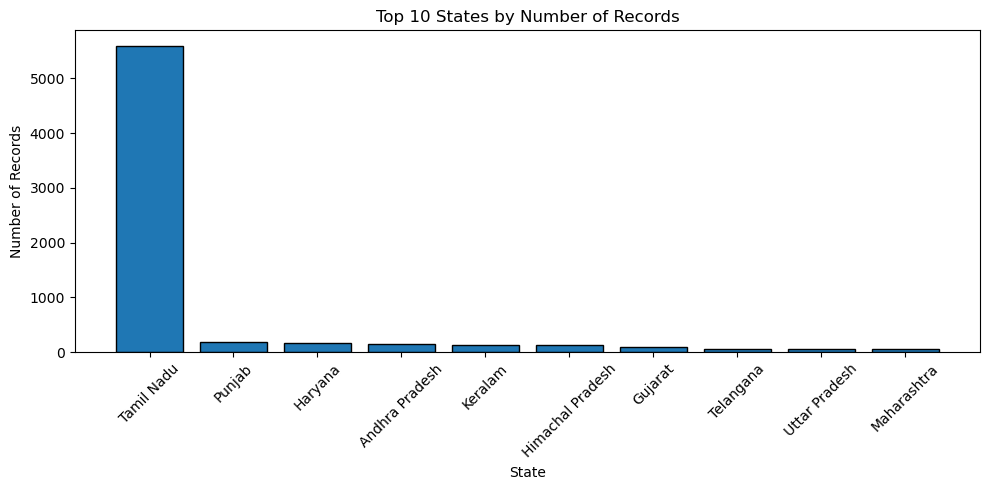

In [27]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_states.index.astype(str),
    top_states.values,
    edgecolor="black"
)

plt.title("Top 10 States by Number of Records")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The bar chart shows the top 10 states based on the number of records available in the dataset. The number of observations varies across the states.

### Inference

This indicates that some states have a higher representation in the dataset than others. The difference in record counts should be considered when analysing regional patterns in agricultural commodity prices.

## Feature Selection

The relevant categorical attributes are selected as input features for predicting the Modal Price.

In [28]:
# Select input features
features = [
    "State",
    "District",
    "Market",
    "Commodity",
    "Variety",
    "Grade"
]

# Define features and target
X = df[features]
y = df["Modal_x0020_Price"]

# Display shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Display selected features
print("\nSelected Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Features Shape: (6862, 6)
Target Shape: (6862,)

Selected Features:
            State  District          Market              Commodity Variety  \
0  Andhra Pradesh  Prakasam  Maddipadu APMC          Paddy(Common)   B P T   
1         Haryana    Rewari      Kosli APMC  Bhindi(Ladies Finger)  Bhindi   
2         Haryana    Rewari      Kosli APMC                 Banana   Other   
3         Haryana    Rewari      Kosli APMC                Cabbage   Other   
4         Haryana    Rewari      Kosli APMC                Pumpkin   Other   

    Grade  
0     FAQ  
1     FAQ  
2  Medium  
3     FAQ  
4     FAQ  

Target Variable:
0    2800.0
1    2000.0
2    2000.0
3    2000.0
4    1000.0
Name: Modal_x0020_Price, dtype: float64


In [29]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5489, 6)
Testing Features: (1373, 6)
Training Target: (5489,)
Testing Target: (1373,)


In [30]:
from sklearn.preprocessing import OneHotEncoder

# Initialize One-Hot Encoder
encoder = OneHotEncoder(handle_unknown="ignore")

# Fit on training data and transform
X_train_encoded = encoder.fit_transform(X_train)

# Transform testing data
X_test_encoded = encoder.transform(X_test)

# Display the encoded data shapes
print("Encoded Training Features:", X_train_encoded.shape)
print("Encoded Testing Features:", X_test_encoded.shape)

Encoded Training Features: (5489, 845)
Encoded Testing Features: (1373, 845)


In [31]:
from sklearn.linear_model import LinearRegression

# Initialize the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_encoded, y_train)

# Predict on testing data
y_pred = linear_model.predict(X_test_encoded)

print("Multiple Linear Regression Model Trained Successfully!")
print("Predictions:", y_pred[:10])

Multiple Linear Regression Model Trained Successfully!
Predictions: [15487.92157315  5536.25304544  5123.32578187  5173.98546706
 13627.97688475  7866.22349698  4423.9174213   5024.80569076
  9598.96258128  6490.8166263 ]


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Multiple Linear Regression Performance
MAE : 1270.3851016713886
MSE : 8599833.853272026
RMSE: 2932.547331804216
R2 Score: 0.7219867077685412


## Plot: Actual vs Predicted Modal Price - Multiple Linear Regression

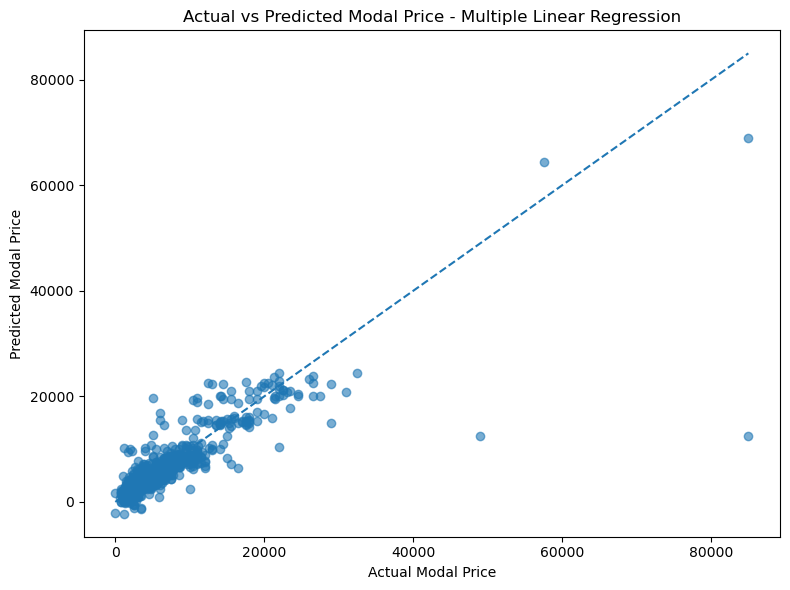

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Modal Price")
plt.ylabel("Predicted Modal Price")
plt.title("Actual vs Predicted Modal Price - Multiple Linear Regression")

plt.tight_layout()
plt.show()

### Insight

The scatter plot compares the actual modal prices with the modal prices predicted by the Multiple Linear Regression model. Points closer to the diagonal reference line represent predictions that are closer to the actual values.

### Inference

This plot helps evaluate how closely the model predictions follow the actual modal prices. A closer alignment with the reference line indicates better prediction performance, while points farther from the line represent larger prediction errors.

## Plot: Residual Plot - Multiple Linear Regression

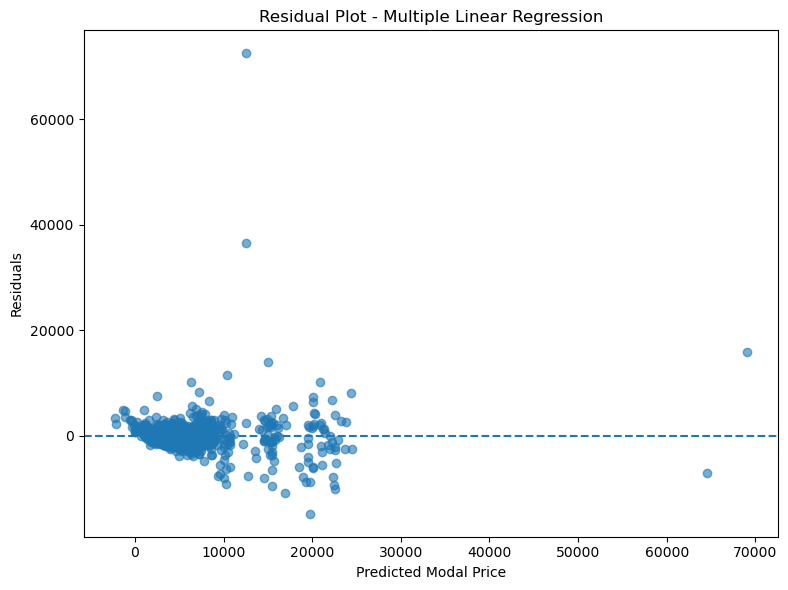

In [43]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Modal Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Linear Regression")

plt.tight_layout()
plt.show()

### Insight

The residual plot shows the difference between the actual modal prices and the predicted modal prices for the Multiple Linear Regression model. The residuals are plotted against the predicted values, with the horizontal line at zero representing perfect prediction.

### Inference

The residuals are distributed around the zero line with some variation across the predicted price values. This indicates that the model captures the general relationship between the input features and modal price, although some prediction errors are present.

## Plot: Residual Distribution - Multiple Linear Regression

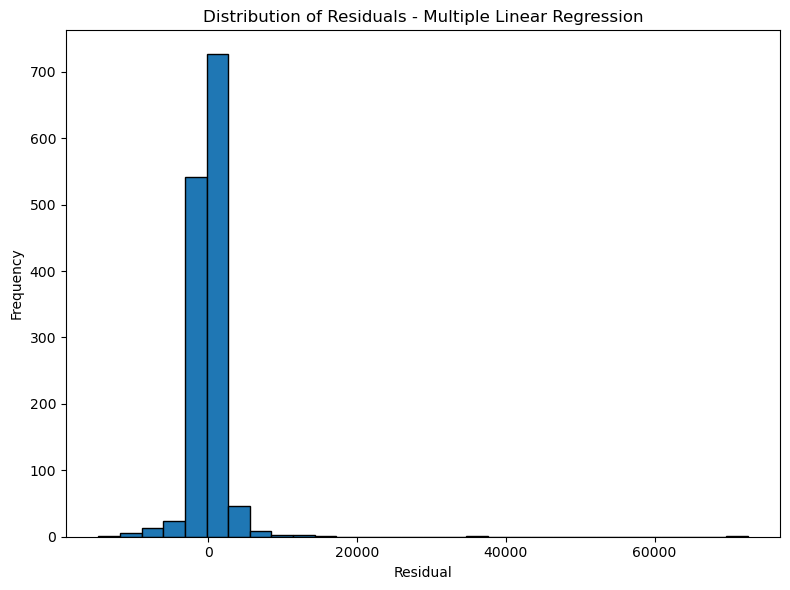

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Multiple Linear Regression")

plt.tight_layout()
plt.show()

### Insight

The histogram shows the distribution of the residuals obtained from the Multiple Linear Regression model. The residuals are distributed around the central value of zero, with some variation on both sides.

### Inference

This indicates that the model has both positive and negative prediction errors. The distribution of residuals helps to assess how the prediction errors are spread across the test data.

## Plot: Q-Q Plot of Residuals - Multiple Linear Regression

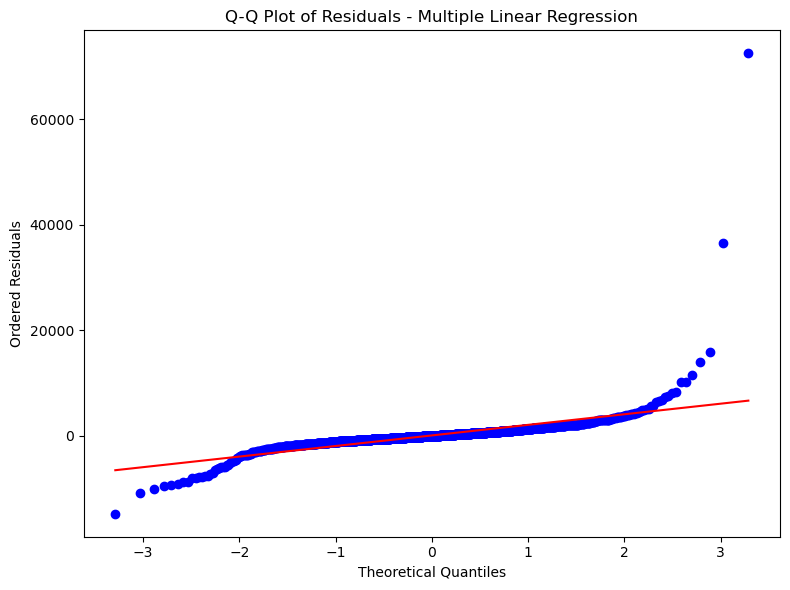

In [45]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals - Multiple Linear Regression")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()

### Insight

The Q-Q plot compares the distribution of the regression residuals with a theoretical normal distribution. Most of the points follow the reference line, while some deviations can be observed, particularly toward the ends.

### Inference

This indicates that the residuals are approximately normally distributed, although some deviations from normality are present at the extreme values.

## Ridge Regression - Hyperparameter Evaluation

Ridge Regression is evaluated using different alpha values to study the effect of regularization on model performance.

In [33]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]

print("Ridge Regression Performance")
print("-" * 60)

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(X_train_encoded, y_train)

    ridge_pred = ridge_model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, ridge_pred)
    mse = mean_squared_error(y_test, ridge_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, ridge_pred)

    print(f"Alpha: {alpha}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 60)

Ridge Regression Performance
------------------------------------------------------------
Alpha: 0.01
MAE : 1276.06
MSE : 8500908.68
RMSE: 2915.63
R2  : 0.7252
------------------------------------------------------------
Alpha: 0.1
MAE : 1283.15
MSE : 7876638.57
RMSE: 2806.53
R2  : 0.7454
------------------------------------------------------------
Alpha: 1
MAE : 1327.20
MSE : 7652736.40
RMSE: 2766.36
R2  : 0.7526
------------------------------------------------------------
Alpha: 10
MAE : 1384.61
MSE : 10794043.48
RMSE: 3285.43
R2  : 0.6511
------------------------------------------------------------
Alpha: 100
MAE : 1849.57
MSE : 17494133.85
RMSE: 4182.60
R2  : 0.4345
------------------------------------------------------------


## Plot: Actual vs Predicted Modal Price - Ridge Regression

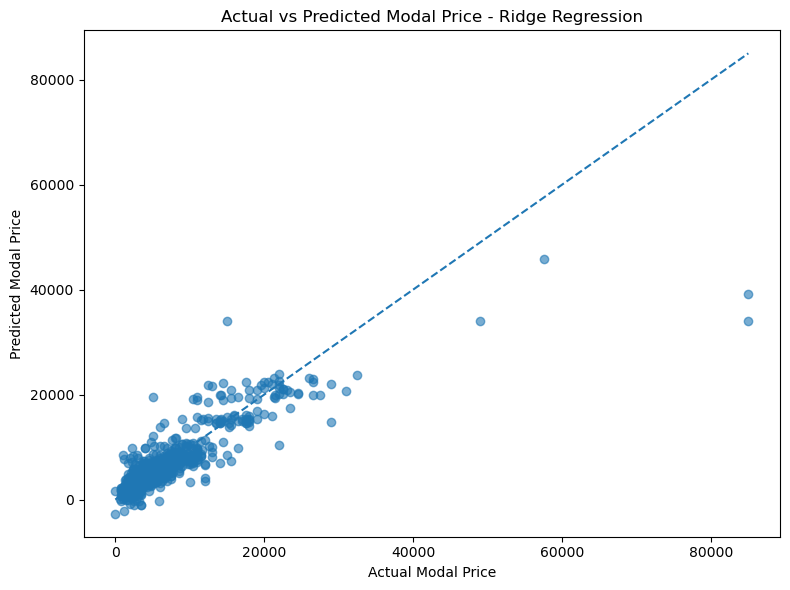

In [46]:
import matplotlib.pyplot as plt

# Train Ridge Regression with selected alpha
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train_encoded, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test_encoded)

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, ridge_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Modal Price")
plt.ylabel("Predicted Modal Price")
plt.title("Actual vs Predicted Modal Price - Ridge Regression")

plt.tight_layout()
plt.show()

### Insight

The scatter plot compares the actual modal prices with the prices predicted by the Ridge Regression model. Points closer to the diagonal reference line represent predictions that are closer to the actual values.

### Inference

The plot shows how closely the Ridge Regression predictions follow the actual modal prices. The alignment of points with the reference line indicates the prediction performance of the Ridge Regression model.

## Plot: Residual Plot - Ridge Regression

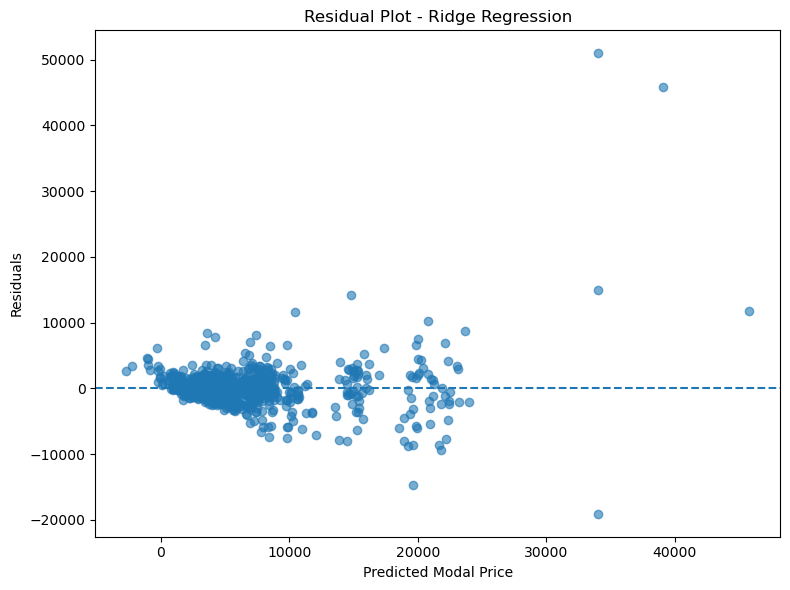

In [47]:
import matplotlib.pyplot as plt

# Calculate residuals
ridge_residuals = y_test - ridge_pred

plt.figure(figsize=(8, 6))

plt.scatter(ridge_pred, ridge_residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Modal Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Ridge Regression")

plt.tight_layout()
plt.show()

### Insight

The residual plot shows the difference between the actual modal prices and the prices predicted by the Ridge Regression model. The residuals are plotted against the predicted values, with the horizontal line at zero representing perfect prediction.

### Inference

The residuals are distributed around the zero line with some variation across the predicted price values. This indicates that the Ridge Regression model captures the general relationship between the selected features and modal price, although some prediction errors are present.

## Plot: Distribution of Residuals - Ridge Regression

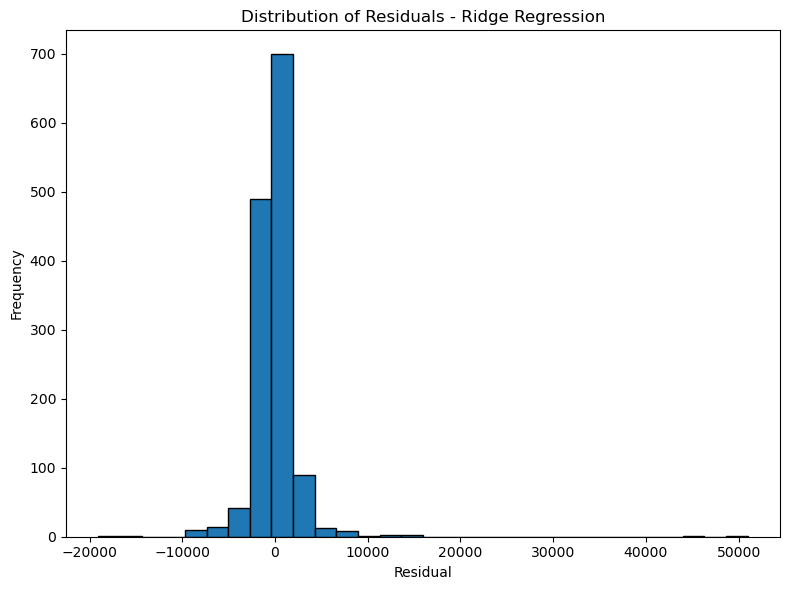

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hist(
    ridge_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Ridge Regression")

plt.tight_layout()
plt.show()

### Insight

The histogram shows the distribution of residuals obtained from the Ridge Regression model. The residuals are distributed around zero, with some variation on both sides.

### Inference

This indicates that the Ridge Regression model produces both positive and negative prediction errors. The residual distribution helps to understand how the prediction errors are spread across the test data.

## Plot: Q-Q Plot of Residuals - Ridge Regression

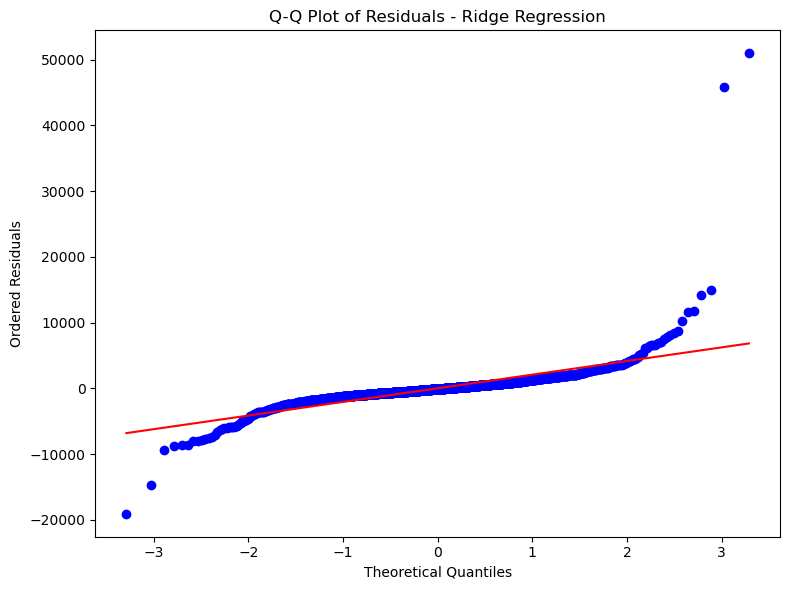

In [49]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

stats.probplot(
    ridge_residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals - Ridge Regression")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()

### Insight

The Q-Q plot compares the Ridge Regression residuals with a theoretical normal distribution. Most of the points follow the reference line, while some deviations can be observed, particularly at the extreme values.

### Inference

This indicates that the Ridge Regression residuals are approximately normally distributed, although some deviations from normality are present at the extreme values.

In [34]:
from sklearn.linear_model import Lasso

# Different hyperparameter values
alphas = [0.01, 0.1, 1, 10, 100]

print("Lasso Regression Performance")
print("-" * 60)

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=10000)

    lasso_model.fit(X_train_encoded, y_train)

    lasso_pred = lasso_model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, lasso_pred)
    mse = mean_squared_error(y_test, lasso_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, lasso_pred)

    print(f"Alpha: {alpha}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 60)

Lasso Regression Performance
------------------------------------------------------------
Alpha: 0.01
MAE : 1283.08
MSE : 9575054.16
RMSE: 3094.36
R2  : 0.6905
------------------------------------------------------------
Alpha: 0.1
MAE : 1277.41
MSE : 9609829.24
RMSE: 3099.97
R2  : 0.6893
------------------------------------------------------------
Alpha: 1
MAE : 1268.05
MSE : 9426278.49
RMSE: 3070.22
R2  : 0.6953
------------------------------------------------------------
Alpha: 10
MAE : 1528.60
MSE : 13266257.68
RMSE: 3642.29
R2  : 0.5711
------------------------------------------------------------
Alpha: 100
MAE : 2672.17
MSE : 25743646.40
RMSE: 5073.82
R2  : 0.1678
------------------------------------------------------------


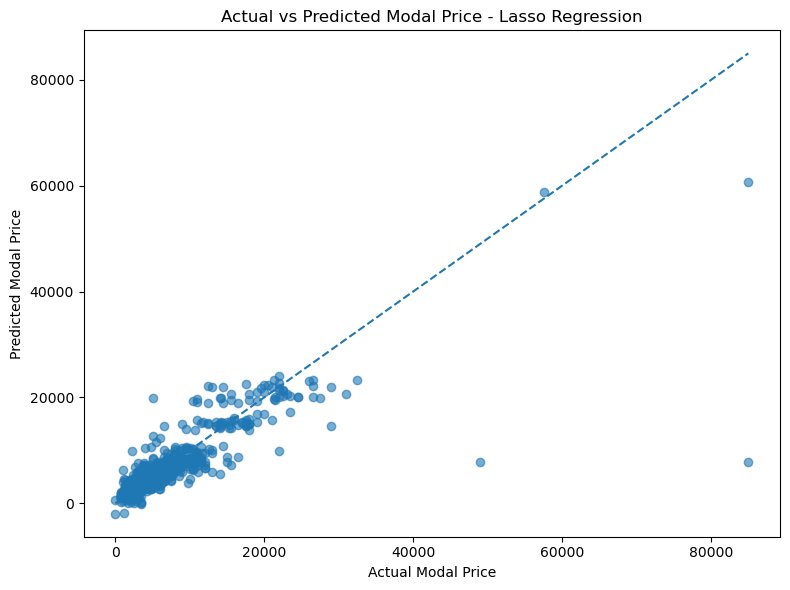

In [72]:
import matplotlib.pyplot as plt

# Train Lasso with selected alpha
lasso_model = Lasso(alpha=1, max_iter=10000)
lasso_model.fit(X_train_encoded, y_train)

# Predictions
lasso_pred = lasso_model.predict(X_test_encoded)

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lasso_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Modal Price")
plt.ylabel("Predicted Modal Price")
plt.title("Actual vs Predicted Modal Price - Lasso Regression")

plt.tight_layout()
plt.show()

## Plot: Actual vs Predicted Modal Price - Lasso Regression

### Insight

The scatter plot compares the actual modal prices with the prices predicted by the Lasso Regression model. Points closer to the diagonal reference line represent predictions that are closer to the actual values.

### Inference

The plot shows how closely the Lasso Regression predictions follow the actual modal prices. The alignment of points with the reference line indicates the prediction performance of the Lasso Regression model.

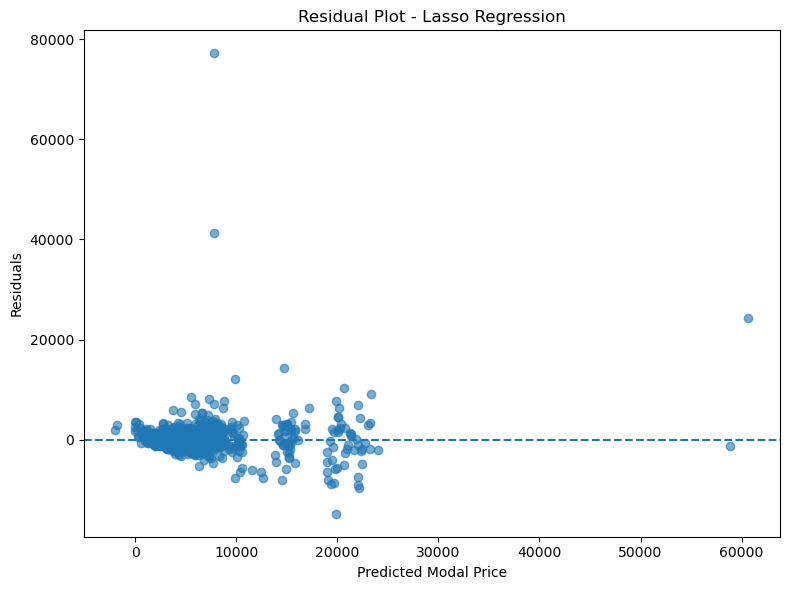

In [51]:
import matplotlib.pyplot as plt

# Calculate residuals
lasso_residuals = y_test - lasso_pred

plt.figure(figsize=(8, 6))

plt.scatter(lasso_pred, lasso_residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Modal Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Lasso Regression")

plt.tight_layout()
plt.show()

## Plot: Residual Plot - Lasso Regression

### Insight

The residual plot shows the difference between the actual modal prices and the prices predicted by the Lasso Regression model. The residuals are plotted against the predicted modal prices, with the horizontal line at zero representing perfect prediction.

### Inference

The residuals are distributed around the zero line with some variation across the predicted price values. This indicates that the Lasso Regression model captures the general relationship between the selected features and modal price, although some prediction errors are present.

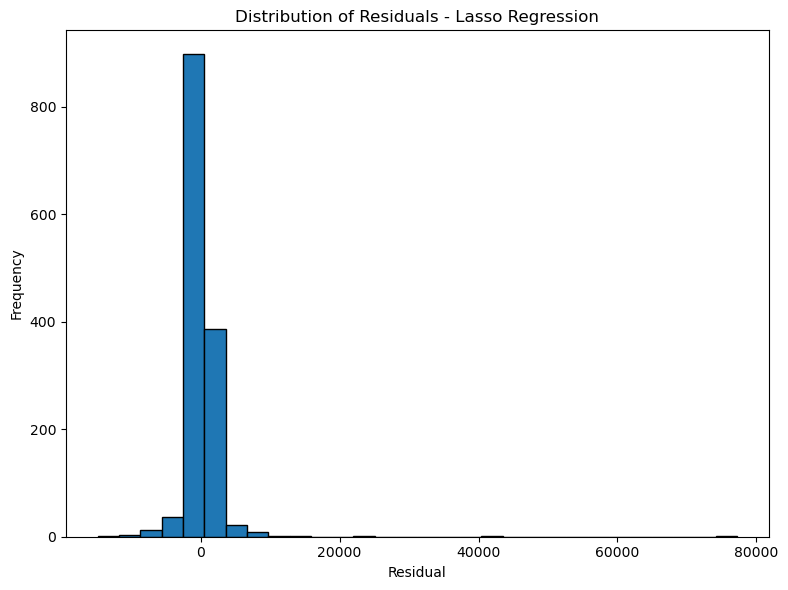

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hist(
    lasso_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Lasso Regression")

plt.tight_layout()
plt.show()

## Plot: Distribution of Residuals - Lasso Regression

### Insight

The histogram shows the distribution of residuals obtained from the Lasso Regression model. The residuals are distributed around zero, with some variation on both sides.

### Inference

This indicates that the Lasso Regression model produces both positive and negative prediction errors. The residual distribution helps to understand how the prediction errors are spread across the test data.

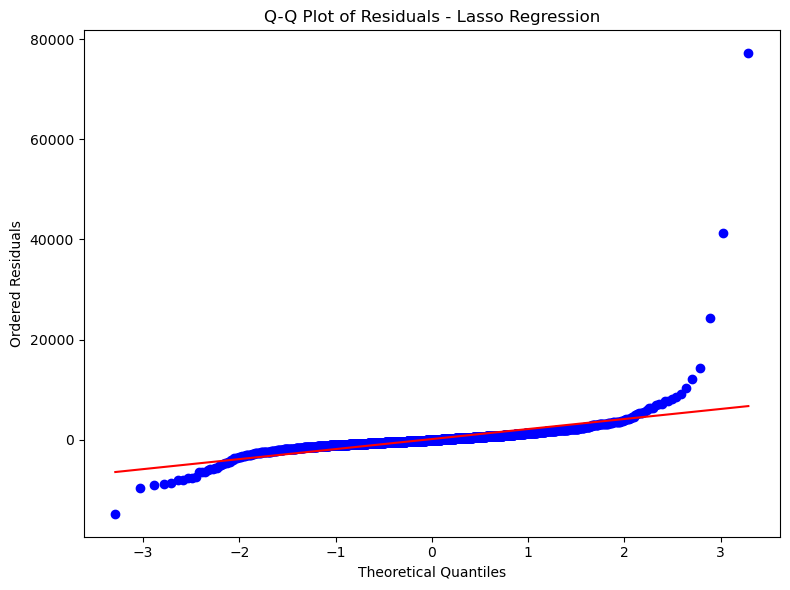

In [53]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

stats.probplot(
    lasso_residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals - Lasso Regression")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()

## Plot: Q-Q Plot of Residuals - Lasso Regression

### Insight

The Q-Q plot compares the Lasso Regression residuals with a theoretical normal distribution. Most of the points follow the reference line, while some deviations can be observed, particularly at the extreme values.

### Inference

This indicates that the Lasso Regression residuals are approximately normally distributed, although some deviations from normality are present at the extreme values.

In [35]:
# Model Comparison

linear_r2 = 0.7219867077685412
linear_mae = 1270.3851016713886
linear_rmse = 2932.547331804216

ridge_r2 = 0.7526
ridge_mae = 1327.20
ridge_rmse = 2766.36

lasso_r2 = 0.6953
lasso_mae = 1268.05
lasso_rmse = 3070.22

print("Model Comparison")
print("-" * 60)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

print("\nRidge Regression")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2  :", ridge_r2)

print("\nLasso Regression")
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R2  :", lasso_r2)

Model Comparison
------------------------------------------------------------
Linear Regression
MAE : 1270.3851016713886
RMSE: 2932.547331804216
R2  : 0.7219867077685412

Ridge Regression
MAE : 1327.2
RMSE: 2766.36
R2  : 0.7526

Lasso Regression
MAE : 1268.05
RMSE: 3070.22
R2  : 0.6953


In [36]:
from sklearn.tree import DecisionTreeRegressor

depths = [3, 5, 7, 10, 15]

print("Decision Tree Regression Performance")
print("-" * 60)

for depth in depths:
    tree_model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    tree_model.fit(X_train_encoded, y_train)

    tree_pred = tree_model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, tree_pred)
    mse = mean_squared_error(y_test, tree_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, tree_pred)

    print(f"Max Depth: {depth}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 60)

Decision Tree Regression Performance
------------------------------------------------------------
Max Depth: 3
MAE : 2762.51
MSE : 28059696.89
RMSE: 5297.14
R2  : 0.0929
------------------------------------------------------------
Max Depth: 5
MAE : 2405.97
MSE : 23754604.08
RMSE: 4873.87
R2  : 0.2321
------------------------------------------------------------
Max Depth: 7
MAE : 2293.85
MSE : 18633510.43
RMSE: 4316.66
R2  : 0.3976
------------------------------------------------------------
Max Depth: 10
MAE : 2198.48
MSE : 15471913.14
RMSE: 3933.44
R2  : 0.4998
------------------------------------------------------------
Max Depth: 15
MAE : 2069.26
MSE : 14540556.55
RMSE: 3813.21
R2  : 0.5299
------------------------------------------------------------


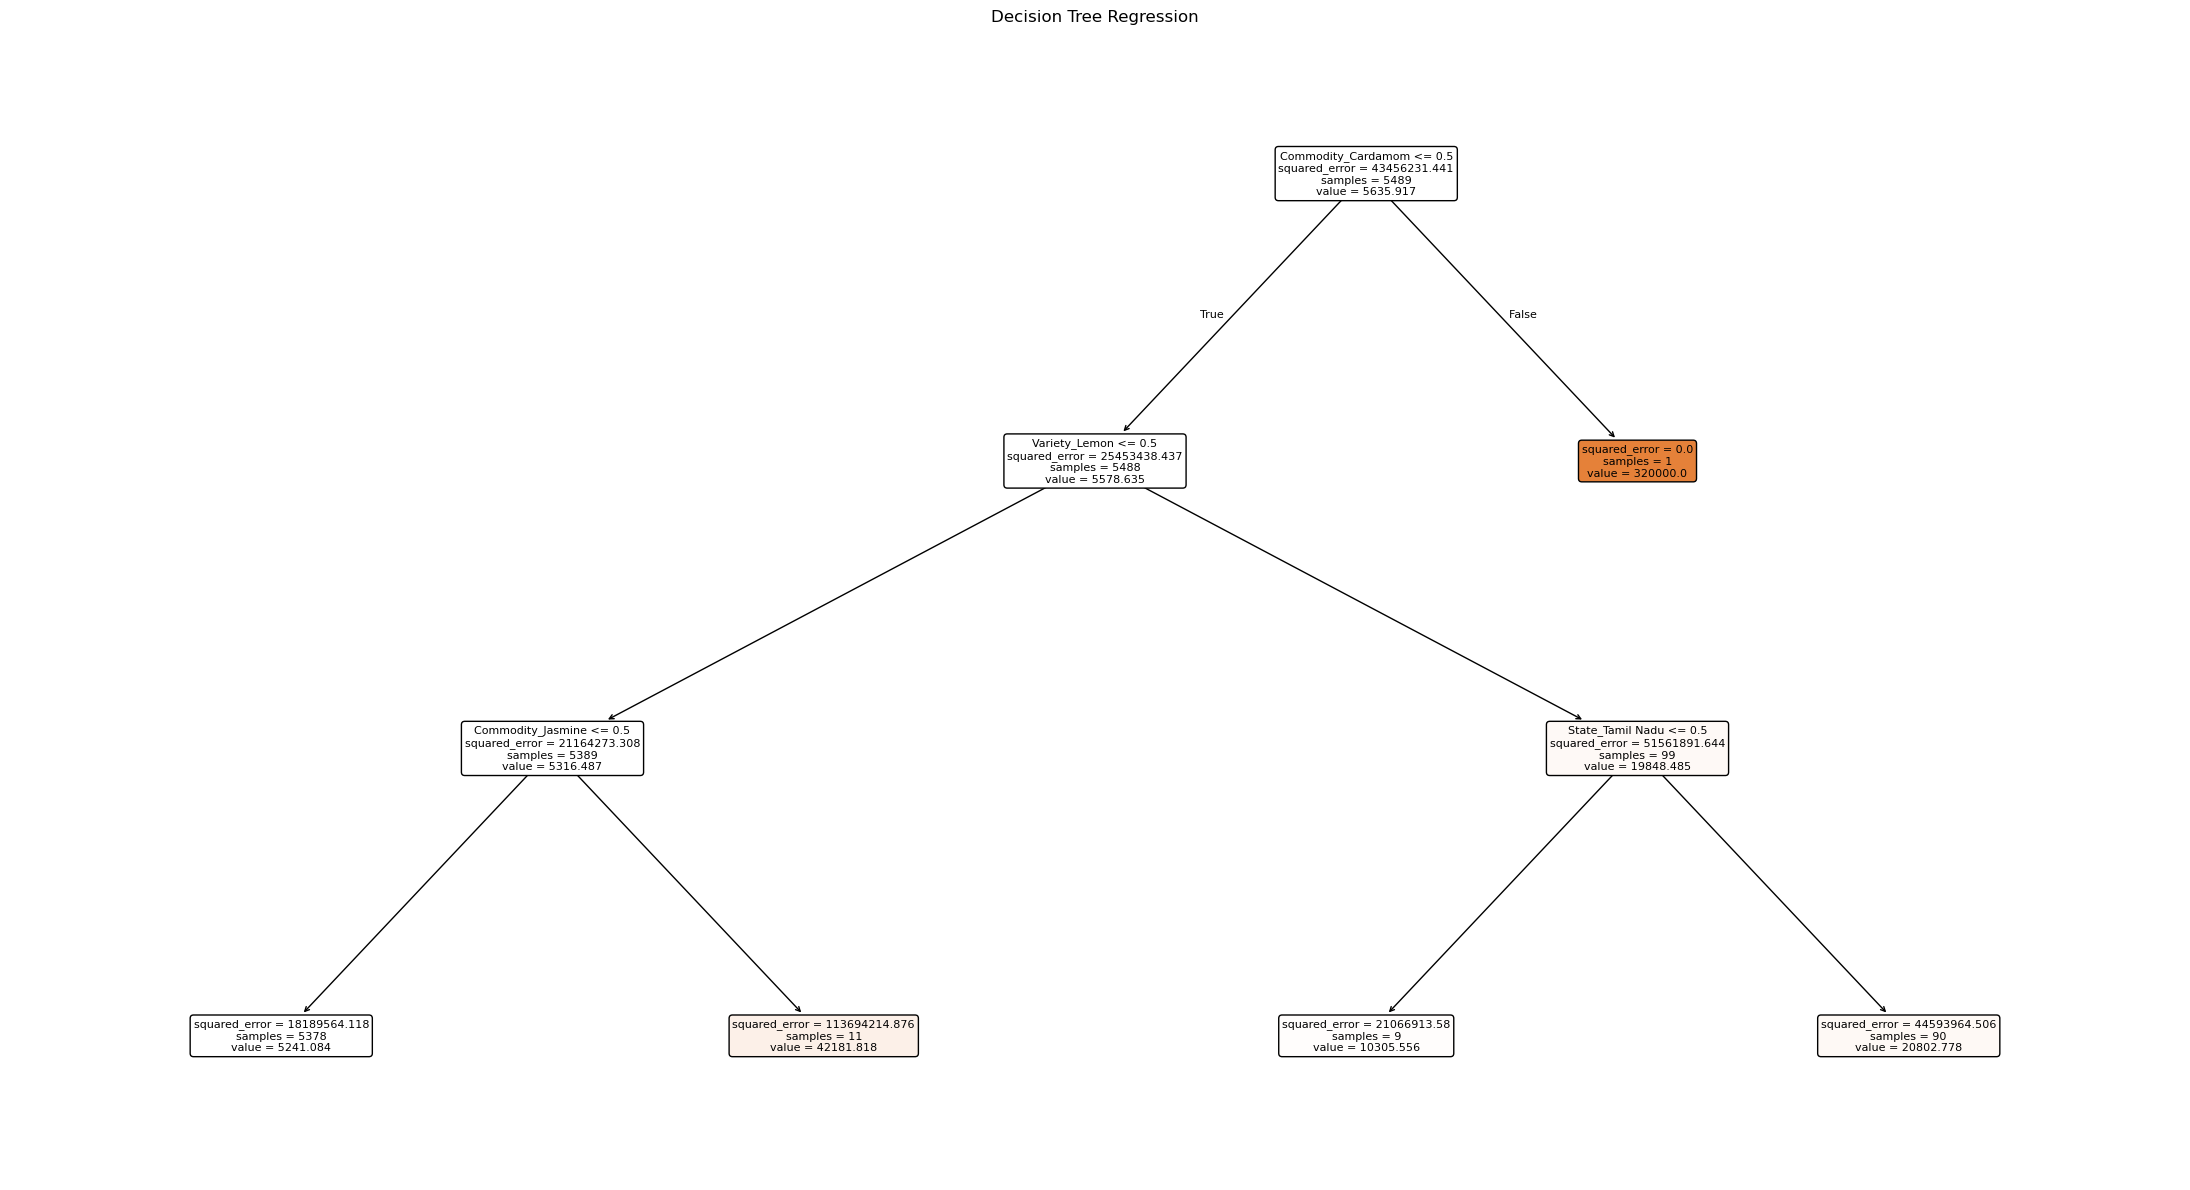

In [41]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Separate small tree only for visualization
tree_visual_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_visual_model.fit(X_train_encoded, y_train)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_visual_model,
    feature_names=encoder.get_feature_names_out(),
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Regression")
plt.tight_layout()
plt.show()

In [57]:
from sklearn.tree import DecisionTreeRegressor

# Final Decision Tree model
final_tree_model = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

final_tree_model.fit(X_train_encoded, y_train)

# Predictions
final_tree_pred = final_tree_model.predict(X_test_encoded)

# Evaluation
tree_mae = mean_absolute_error(y_test, final_tree_pred)
tree_mse = mean_squared_error(y_test, final_tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, final_tree_pred)

print("Final Decision Tree Regression Performance")
print("-" * 60)
print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE:", tree_rmse)
print("R2  :", tree_r2)

Final Decision Tree Regression Performance
------------------------------------------------------------
MAE : 2069.261185929062
MSE : 14540556.54676255
RMSE: 3813.2081698699
R2  : 0.5299365004702866


In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Parameter grid
param_grid = {
    "max_depth": [5, 7, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Decision Tree model
tree_model = DecisionTreeRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    tree_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best Cross-Validation R2 Score:
0.5367134281692222


In [59]:
# Best Decision Tree Model
best_tree_model = grid_search.best_estimator_

# Predictions on test data
best_tree_pred = best_tree_model.predict(X_test_encoded)

# Evaluation metrics
best_tree_mae = mean_absolute_error(y_test, best_tree_pred)
best_tree_mse = mean_squared_error(y_test, best_tree_pred)
best_tree_rmse = np.sqrt(best_tree_mse)
best_tree_r2 = r2_score(y_test, best_tree_pred)

print("Tuned Decision Tree Regression Performance")
print("-" * 60)
print("MAE :", best_tree_mae)
print("MSE :", best_tree_mse)
print("RMSE:", best_tree_rmse)
print("R2  :", best_tree_r2)

Tuned Decision Tree Regression Performance
------------------------------------------------------------
MAE : 2063.8093441316264
MSE : 14351620.310738968
RMSE: 3788.3532452424456
R2  : 0.5360443841683828


In [60]:
# Final Model Comparison

models = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Decision Tree"
]

mae_scores = [
    linear_mae,
    ridge_mae,
    lasso_mae,
    best_tree_mae
]

rmse_scores = [
    linear_rmse,
    ridge_rmse,
    lasso_rmse,
    best_tree_rmse
]

r2_scores = [
    linear_r2,
    ridge_r2,
    lasso_r2,
    best_tree_r2
]

print("Final Model Comparison")
print("-" * 70)

for i in range(len(models)):
    print(models[i])
    print("MAE :", round(mae_scores[i], 2))
    print("RMSE:", round(rmse_scores[i], 2))
    print("R2  :", round(r2_scores[i], 4))
    print("-" * 70)

Final Model Comparison
----------------------------------------------------------------------
Linear Regression
MAE : 1270.39
RMSE: 2932.55
R2  : 0.722
----------------------------------------------------------------------
Ridge Regression
MAE : 1327.2
RMSE: 2766.36
R2  : 0.7526
----------------------------------------------------------------------
Lasso Regression
MAE : 1268.05
RMSE: 3070.22
R2  : 0.6953
----------------------------------------------------------------------
Decision Tree
MAE : 2063.81
RMSE: 3788.35
R2  : 0.536
----------------------------------------------------------------------


In [61]:
# Prepare data for RAG / Price Query

rag_data = df[
    [
        "State",
        "District",
        "Market",
        "Commodity",
        "Variety",
        "Grade",
        "Arrival_Date",
        "Modal_x0020_Price"
    ]
].copy()

print("RAG Data Shape:", rag_data.shape)
print("\nRAG Data Sample:")
print(rag_data.head())

RAG Data Shape: (6862, 8)

RAG Data Sample:
            State  District          Market              Commodity Variety  \
0  Andhra Pradesh  Prakasam  Maddipadu APMC          Paddy(Common)   B P T   
1         Haryana    Rewari      Kosli APMC  Bhindi(Ladies Finger)  Bhindi   
2         Haryana    Rewari      Kosli APMC                 Banana   Other   
3         Haryana    Rewari      Kosli APMC                Cabbage   Other   
4         Haryana    Rewari      Kosli APMC                Pumpkin   Other   

    Grade Arrival_Date  Modal_x0020_Price  
0     FAQ   21/09/2026             2800.0  
1     FAQ   21/09/2026             2000.0  
2  Medium   21/09/2026             2000.0  
3     FAQ   21/09/2026             2000.0  
4     FAQ   21/09/2026             1000.0  


In [62]:
def search_price(commodity_name):
    result = rag_data[
        rag_data["Commodity"].str.contains(
            commodity_name,
            case=False,
            na=False
        )
    ]

    if result.empty:
        print("Commodity not found.")
    else:
        print("Price Information")
        print("-" * 50)
        print(
            result[
                [
                    "State",
                    "District",
                    "Market",
                    "Commodity",
                    "Variety",
                    "Grade",
                    "Arrival_Date",
                    "Modal_x0020_Price"
                ]
            ].head(10)
        )

In [63]:
search_price("Onion")

Price Information
--------------------------------------------------
          State    District                           Market    Commodity  \
39      Keralam   Ernakulam               Perumbavoor Market        Onion   
53   Tamil Nadu       Erode     Perundurai(Uzhavar Sandhai )  Onion Green   
74   Tamil Nadu  Dharmapuri     Pennagaram(Uzhavar Sandhai )        Onion   
101  Tamil Nadu    Dindigul       Dindigul(Uzhavar Sandhai )  Onion Green   
102  Tamil Nadu    Dindigul         Palani(Uzhavar Sandhai )        Onion   
110  Tamil Nadu    Dindigul         Palani(Uzhavar Sandhai )  Onion Green   
143  Tamil Nadu  Dharmapuri    Karimangalam(Uzhavar Sandhai)  Onion Green   
175  Tamil Nadu     Madurai        Anaiyur(Uzhavar Sandhai )  Onion Green   
176  Tamil Nadu     Madurai    Usilampatti(Uzhavar Sandhai )        Onion   
192  Tamil Nadu    Namakkal  Kumarapalayam(Uzhavar Sandhai )  Onion Green   

         Variety   Grade Arrival_Date  Modal_x0020_Price  
39         Onion  Medium

In [64]:
def price_query(commodity_name):
    result = rag_data[
        rag_data["Commodity"].str.contains(
            commodity_name,
            case=False,
            na=False
        )
    ]

    if result.empty:
        return f"Sorry, I could not find price information for {commodity_name}."

    print(f"Price information for {commodity_name}:")
    print("-" * 50)

    for _, row in result.head(5).iterrows():
        print(
            f"{row['Commodity']} | "
            f"{row['Market']} | "
            f"Modal Price: ₹{row['Modal_x0020_Price']:.2f}"
        )

In [65]:
price_query("Onion")

Price information for Onion:
--------------------------------------------------
Onion | Perumbavoor Market | Modal Price: ₹5500.00
Onion Green | Perundurai(Uzhavar Sandhai ) | Modal Price: ₹7500.00
Onion | Pennagaram(Uzhavar Sandhai ) | Modal Price: ₹6250.00
Onion Green | Dindigul(Uzhavar Sandhai ) | Modal Price: ₹8500.00
Onion | Palani(Uzhavar Sandhai ) | Modal Price: ₹5750.00


In [66]:
def ask_price(question):
    question = question.lower()

    # Remove common question words
    for word in ["what", "is", "the", "price", "of", "modal", "for", "?"]:
        question = question.replace(word, " ")

    commodity_name = question.strip()

    if commodity_name:
        price_query(commodity_name)
    else:
        print("Please enter a commodity name.")

In [67]:
ask_price("What is the price of Onion?")

Price information for onion:
--------------------------------------------------
Onion | Perumbavoor Market | Modal Price: ₹5500.00
Onion Green | Perundurai(Uzhavar Sandhai ) | Modal Price: ₹7500.00
Onion | Pennagaram(Uzhavar Sandhai ) | Modal Price: ₹6250.00
Onion Green | Dindigul(Uzhavar Sandhai ) | Modal Price: ₹8500.00
Onion | Palani(Uzhavar Sandhai ) | Modal Price: ₹5750.00


In [68]:
print("Agricultural Commodity Price Chatbot")
print("Type 'exit' to stop.")
print("-" * 50)

while True:
    question = input("You: ")

    if question.lower() == "exit":
        print("Chatbot: Thank you!")
        break

    print("Chatbot:")
    ask_price(question)
    print()

Agricultural Commodity Price Chatbot
Type 'exit' to stop.
--------------------------------------------------


You:  What is the price of Onion?


Chatbot:
Price information for onion:
--------------------------------------------------
Onion | Perumbavoor Market | Modal Price: ₹5500.00
Onion Green | Perundurai(Uzhavar Sandhai ) | Modal Price: ₹7500.00
Onion | Pennagaram(Uzhavar Sandhai ) | Modal Price: ₹6250.00
Onion Green | Dindigul(Uzhavar Sandhai ) | Modal Price: ₹8500.00
Onion | Palani(Uzhavar Sandhai ) | Modal Price: ₹5750.00



You:  exit


Chatbot: Thank you!


In [69]:
# Create final model results table

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        best_tree_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        best_tree_rmse
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        best_tree_r2
    ]
})

print("Final Model Results")
print(model_results)

Final Model Results
               Model          MAE         RMSE  R2 Score
0  Linear Regression  1270.385102  2932.547332  0.721987
1   Ridge Regression  1327.200000  2766.360000  0.752600
2   Lasso Regression  1268.050000  3070.220000  0.695300
3      Decision Tree  2063.809344  3788.353245  0.536044


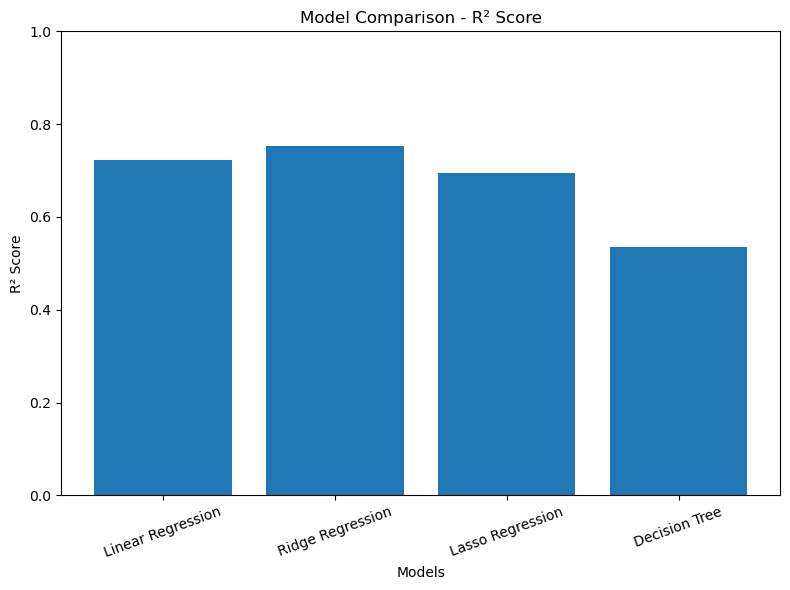

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.bar(
    model_results["Model"],
    model_results["R2 Score"]
)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [71]:
# Dashboard Summary

print("Agricultural Commodity Price Prediction Dashboard")
print("=" * 60)

print("Dataset Records :", len(df))
print("Number of Features :", len(df.columns))
print("Number of Commodities :", df["Commodity"].nunique())

print("\nPrice Summary")
print("-" * 60)
print("Average Minimum Price :", round(df["Min_x0020_Price"].mean(), 2))
print("Average Maximum Price :", round(df["Max_x0020_Price"].mean(), 2))
print("Average Modal Price  :", round(df["Modal_x0020_Price"].mean(), 2))

print("\nRAG / Chatbot Status")
print("-" * 60)
print("Price Query Feature : Available")
print("Commodity Search    : Available")

Agricultural Commodity Price Prediction Dashboard
Dataset Records : 6862
Number of Features : 10
Number of Commodities : 139

Price Summary
------------------------------------------------------------
Average Minimum Price : 5294.38
Average Maximum Price : 5989.75
Average Modal Price  : 5643.6

RAG / Chatbot Status
------------------------------------------------------------
Price Query Feature : Available
Commodity Search    : Available


## Result

The agricultural commodity price prediction system was successfully developed using machine learning techniques. Exploratory Data Analysis was performed to understand commodity prices, states, districts, grades, and price relationships.

Multiple Linear Regression, Ridge Regression, Lasso Regression, and Decision Tree Regression models were implemented and evaluated using MAE, MSE, RMSE, and R² metrics. Different hyperparameter values were also tested to study their effect on model performance.

A RAG-based price query system was developed using the collected agricultural market data, allowing users to search for commodity prices based on market information.

Finally, a dashboard was created to present the dataset summary, EDA visualizations, model performance, commodity search, and price-query functionality in an interactive manner.